In [1]:
!pip install tsfresh

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 206.7 kB/s eta 0:00:00 kB/s eta 0:00:01:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 964.8 kB/s eta 0:00:00m eta 0:00:010:01:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.9/232.9 kB 127.6 kB/s eta 0:00:001m127.0 kB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 2.5 MB/s eta 0:00:00m eta 0:00:010:01:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.5/176.5 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 2.0 MB/s eta 0:00:00m eta 0:00:010:00:010m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 365.7 kB/s eta 0:00:00m eta 0:00:010:00:03


### FEATURES ARRANGEMENT

In [5]:
import pandas as pd
import numpy as np
import os
import glob

In [6]:
IndCSVs = "/home/student24/region_timeseries_output"
Patt = os.path.join(IndCSVs, "*_region_timeseries.csv")
csv_files = sorted(glob.glob(Patt))

print("Found these CSV files:")
for path in csv_files:
    print("  ", path)

Found these CSV files:
   /home/student24/region_timeseries_output/UPENN-GBM-00029_region_timeseries.csv
   /home/student24/region_timeseries_output/UPENN-GBM-00054_region_timeseries.csv
   /home/student24/region_timeseries_output/UPENN-GBM-00071_region_timeseries.csv
   /home/student24/region_timeseries_output/UPENN-GBM-00125_region_timeseries.csv
   /home/student24/region_timeseries_output/UPENN-GBM-00249_region_timeseries.csv
   /home/student24/region_timeseries_output/UPENN-GBM-00365_region_timeseries.csv
   /home/student24/region_timeseries_output/UPENN-GBM-00416_region_timeseries.csv
   /home/student24/region_timeseries_output/UPENN-GBM-00444_region_timeseries.csv
   /home/student24/region_timeseries_output/UPENN-GBM-00519_region_timeseries.csv
   /home/student24/region_timeseries_output/UPENN-GBM-00564_region_timeseries.csv
   /home/student24/region_timeseries_output/UPENN-GBM-00567_region_timeseries.csv
   /home/student24/region_timeseries_output/UPENN-GBM-00619_region_timeseri

In [7]:
wanted_regions = {
    "rh_volume_superiorfrontal",
    "lh_volume_superiorfrontal",
    "lh_volume_rostralmiddlefrontal",
}

In [9]:
New_Format = []

for csv_path in csv_files:
    filename = os.path.basename(csv_path)
    subjectID = filename.split("_region_timeseries.csv")[0]

    Def_data = pd.read_csv(csv_path)
  
    Def_data = Def_data.copy()
    Def_data["time"] = np.arange(Def_data.shape[0])

    New_data = Def_data.melt(
        id_vars=["time"],
        var_name="region",
        value_name="value"
    )

    New_data = New_data[New_data["region"].isin(wanted_regions)].copy()

    New_data["id"] = subjectID + "_" + New_data["region"]

    New_Format.append(New_data)

print(New_Format[0].head(8))

Example of  New data for the first subject:
   time                     region       value  \
0     0  rh_volume_superiorfrontal  600.621057   
1     1  rh_volume_superiorfrontal  599.477299   
2     2  rh_volume_superiorfrontal  600.777032   
3     3  rh_volume_superiorfrontal  602.204496   
4     4  rh_volume_superiorfrontal  601.317670   
5     5  rh_volume_superiorfrontal  604.202907   
6     6  rh_volume_superiorfrontal  603.777719   
7     7  rh_volume_superiorfrontal  606.786628   

                                          id  
0  UPENN-GBM-00029_rh_volume_superiorfrontal  
1  UPENN-GBM-00029_rh_volume_superiorfrontal  
2  UPENN-GBM-00029_rh_volume_superiorfrontal  
3  UPENN-GBM-00029_rh_volume_superiorfrontal  
4  UPENN-GBM-00029_rh_volume_superiorfrontal  
5  UPENN-GBM-00029_rh_volume_superiorfrontal  
6  UPENN-GBM-00029_rh_volume_superiorfrontal  
7  UPENN-GBM-00029_rh_volume_superiorfrontal  


In [10]:
combined_featuresL = pd.concat(New_Format, ignore_index=True)

print("Combined shape:", combined_featuresL.shape)
print("Columns:", combined_featuresL.columns.tolist())

combined_featuresL = combined_featuresL[combined_featuresL["time"] < 45].copy()
combined_featuresL = combined_featuresL[["id", "time", "value"]]

output_csv = os.path.join(IndCSVs, "Complete_subj_long.csv")
combined_featuresL.to_csv(output_csv, index=False)
print(f" Long‐format data saved to: {output_csv}")

Combined shape: (20985, 4)
Columns: ['time', 'region', 'value', 'id']
 Long‐format data saved to: /home/student24/region_timeseries_output/Complete_subj_long.csv


In [12]:
combined_featuresL.head()

,id,time,value
0,UPENN-GBM-00029_rh_volume_superiorfrontal,0,600.621057
1,UPENN-GBM-00029_rh_volume_superiorfrontal,1,599.477299
2,UPENN-GBM-00029_rh_volume_superiorfrontal,2,600.777032
3,UPENN-GBM-00029_rh_volume_superiorfrontal,3,602.204496
4,UPENN-GBM-00029_rh_volume_superiorfrontal,4,601.317670


In [13]:
len(combined_featuresL)

4446

#### PLOTTING TIME SERIES PATTERN

In [17]:
merged_data = pd.merge(Sample_data, STATUS, on="id")

NameError: name 'STATUS' is not defined

In [218]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")

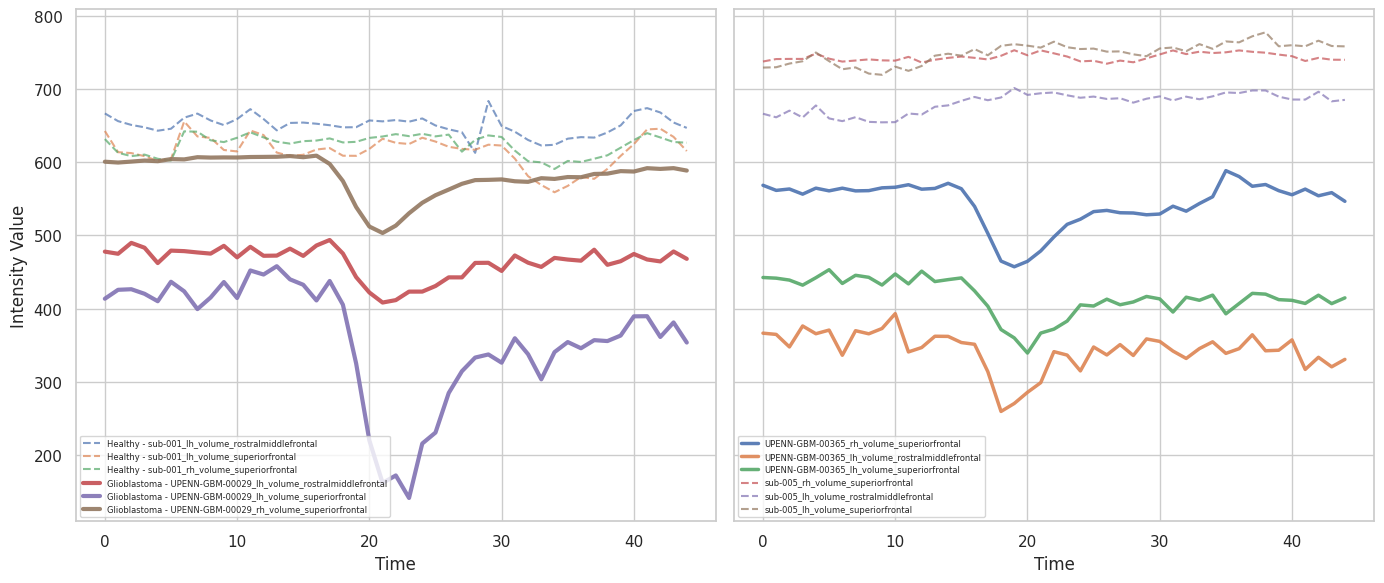

In [265]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for label in [0, 1]:
    subset = merged_data[merged_data["label"] == label]
    for i, (sub_id, group) in enumerate(subset.groupby("id")):
        if i >= 3: 
            break
        axes[0].plot(group["time"], group["value"], label=f"{'Glioblastoma' if label else 'Healthy'} - {sub_id}",
                linewidth=3 if label == 1 else 1.5,
            alpha=0.9 if label == 1 else 0.7 ,
             linestyle='-' if  label == 1  else '--')
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Intensity Value")
axes[0].legend(loc='lower left', fontsize=6)


selected_subjects = ["UPENN-GBM-00365", "sub-005"]

subset = merged_data[merged_data['id'].str.contains('|'.join(selected_subjects))]

for uid in subset['id'].unique():
    is_gbm = uid.startswith("UPENN-GBM")
    sub_data = subset[subset['id'] == uid]
    axes[1].plot(sub_data['time'], sub_data['value'],
             label=uid,
             linewidth=2.5 if is_gbm else 1.5,
             alpha=0.9 if is_gbm else 0.7,
             linestyle='-' if is_gbm else '--')

axes[1].set_xlabel("Time")
axes[1].legend(fontsize=6)
plt.savefig("intensity_trend.png", dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

#### FEATURE IMPORTANCE (BARPLOT)

In [18]:
import pandas as pd

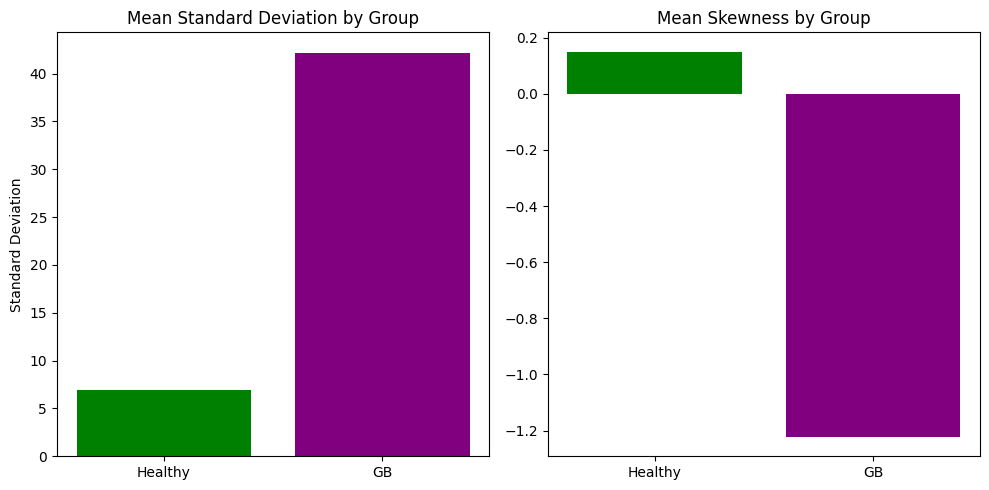

In [71]:
summary = Class_features.groupby('label').agg({
    'value__standard_deviation': 'mean',
    'value__skewness': 'mean'
}).reset_index()

labels = ['Healthy', 'GB']

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].bar(labels, summary['value__standard_deviation'], color=['green', 'purple'])
axes[0].set_title('Mean Standard Deviation by Group')
axes[0].set_ylabel('Standard Deviation')

axes[1].bar(labels, summary['value__skewness'], color=['green', 'purple'])
axes[1].set_title('Mean Skewness by Group')
plt.savefig("features.png", dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()


In [282]:
print("Summary statistics for Kurtosis:")
print(
    Class_features.groupby("label")['value__kurtosis'].describe()
)

Summary statistics for Kurtosis:
       count      mean       std       min       25%       50%       75%  \
label                                                                      
0       60.0  0.203034  1.794163 -1.326941 -0.559138 -0.236551  0.423522   
1       39.0  2.003354  2.160100 -1.602031  0.133085  1.492119  3.605171   

             max  
label             
0      12.239308  
1       6.022372  


In [284]:
print("Summary statistics for Absolute energy:")
print(
    Class_features.groupby("label")["value__abs_energy"].describe()
)

Summary statistics for Absolute energy:
       count          mean           std           min           25%  \
label                                                                  
0       60.0  2.300239e+07  7.191121e+06  9.218184e+06  1.741329e+07   
1       39.0  1.291265e+07  8.096299e+06  2.461827e+04  7.246531e+06   

                50%           75%           max  
label                                            
0      2.246338e+07  2.712062e+07  4.293095e+07  
1      1.018197e+07  1.912271e+07  3.237938e+07  


In [285]:
print("Summary statistics for autocorrelation__lag_1:")
print(
    Class_features.groupby("label")["value__autocorrelation__lag_1"].describe()
)

Summary statistics for autocorrelation__lag_1:
       count      mean       std       min       25%       50%       75%  \
label                                                                      
0       60.0  0.443886  0.309808 -0.502099  0.281315  0.463334  0.684084   
1       39.0  0.814424  0.221794  0.017779  0.790024  0.902771  0.926647   

            max  
label            
0      0.936808  
1      0.989659  


In [19]:
from tsfresh.feature_extraction import ComprehensiveFCParameters
from tsfresh import extract_features

master_params = ComprehensiveFCParameters()

fc_parameters = {
    "mean":               master_params["mean"],
    "standard_deviation": master_params["standard_deviation"],
    "skewness":           master_params["skewness"],
    "kurtosis":           master_params["kurtosis"],
    "abs_energy":         master_params["abs_energy"],
    "autocorrelation":    [{"lag": 1}],
    "number_peaks":       [{"n": 1}],
}

features_ = extract_features(
    combined_featuresL,
    column_id="id",
    column_sort="time",
    column_value="value",
    default_fc_parameters=fc_parameters,
    impute_function=None
)

print( features_.shape)
print("Columns:", features_.columns.tolist())


Feature Extraction: 100%|█████████████████████| 25/25 [00:00<00:00, 5535.14it/s]

Shape of extracted features: (99, 7)
Columns: ['value__mean', 'value__standard_deviation', 'value__skewness', 'value__kurtosis', 'value__abs_energy', 'value__autocorrelation__lag_1', 'value__number_peaks__n_1']


In [24]:
features_.shape

(99, 7)

In [25]:
features_.tail()

,value__mean,value__standard_deviation,value__skewness,value__kurtosis,value__abs_energy,value__autocorrelation__lag_1,value__number_peaks__n_1
sub-085_lh_volume_superiorfrontal,676.134186,5.752193,0.107199,-1.284044,2.057357e+07,0.611484,13.0
sub-085_rh_volume_superiorfrontal,565.190212,9.565033,-0.343454,-0.242115,1.437892e+07,0.515080,14.0
sub-098_lh_volume_rostralmiddlefrontal,742.835727,1.705254,-0.360533,-0.230987,2.483135e+07,0.113704,14.0
sub-098_lh_volume_superiorfrontal,807.805373,1.162234,0.096458,-0.631420,2.936479e+07,0.353493,12.0
sub-098_rh_volume_superiorfrontal,774.437166,1.395239,0.205065,-0.167348,2.698897e+07,0.203918,13.0


In [26]:
features_[features_["value__number_peaks__n_1"] >10]

,value__mean,value__standard_deviation,value__skewness,value__kurtosis,value__abs_energy,value__autocorrelation__lag_1,value__number_peaks__n_1
UPENN-GBM-00029_lh_volume_rostralmiddlefrontal,463.754621,20.723577,-1.195950,0.760254,9.697402e+06,0.834811,13.0
UPENN-GBM-00029_lh_volume_superiorfrontal,359.228249,79.722392,-1.187153,0.863953,6.093027e+06,0.934735,13.0
UPENN-GBM-00029_rh_volume_superiorfrontal,581.808553,27.100578,-1.402505,1.492119,1.526560e+07,0.959319,12.0
UPENN-GBM-00054_lh_volume_superiorfrontal,293.640612,19.244205,-1.990894,3.425098,3.896782e+06,0.742955,14.0
UPENN-GBM-00054_rh_volume_superiorfrontal,23.356384,1.245798,-2.125285,3.785244,2.461827e+04,0.707228,13.0
...,...,...,...,...,...,...,...
sub-085_lh_volume_superiorfrontal,676.134186,5.752193,0.107199,-1.284044,2.057357e+07,0.611484,13.0
sub-085_rh_volume_superiorfrontal,565.190212,9.565033,-0.343454,-0.242115,1.437892e+07,0.515080,14.0
sub-098_lh_volume_rostralmiddlefrontal,742.835727,1.705254,-0.360533,-0.230987,2.483135e+07,0.113704,14.0
sub-098_lh_volume_superiorfrontal,807.805373,1.162234,0.096458,-0.631420,2.936479e+07,0.353493,12.0


In [27]:
STATUS = pd.DataFrame({
    "id": features_.index.tolist()
})
STATUS["label"] = STATUS["id"].str.startswith("UPENN-GBM").astype(int)

In [28]:
Class_features = features_.merge(
    STATUS, left_index=True, right_on="id"
)

Class_features.head()

,value__mean,value__standard_deviation,value__skewness,value__kurtosis,value__abs_energy,value__autocorrelation__lag_1,value__number_peaks__n_1,id,label
0,463.754621,20.723577,-1.195950,0.760254,9.697402e+06,0.834811,13.0,UPENN-GBM-00029_lh_volume_rostralmiddlefrontal,1
1,359.228249,79.722392,-1.187153,0.863953,6.093027e+06,0.934735,13.0,UPENN-GBM-00029_lh_volume_superiorfrontal,1
2,581.808553,27.100578,-1.402505,1.492119,1.526560e+07,0.959319,12.0,UPENN-GBM-00029_rh_volume_superiorfrontal,1
3,265.657674,12.260260,-1.269244,1.363263,3.182594e+06,0.557924,10.0,UPENN-GBM-00054_lh_volume_rostralmiddlefrontal,1
4,293.640612,19.244205,-1.990894,3.425098,3.896782e+06,0.742955,14.0,UPENN-GBM-00054_lh_volume_superiorfrontal,1


In [66]:
Class_features.columns

Index(['value__mean', 'value__standard_deviation', 'value__skewness',
       'value__kurtosis', 'value__abs_energy', 'value__autocorrelation__lag_1',
       'id', 'label'],
      dtype='object')

In [30]:
import matplotlib.pyplot as plt

In [32]:
Class_features.head()

,value__mean,value__standard_deviation,value__skewness,value__kurtosis,value__abs_energy,value__autocorrelation__lag_1,value__number_peaks__n_1,id,label
0,463.754621,20.723577,-1.195950,0.760254,9.697402e+06,0.834811,13.0,UPENN-GBM-00029_lh_volume_rostralmiddlefrontal,1
1,359.228249,79.722392,-1.187153,0.863953,6.093027e+06,0.934735,13.0,UPENN-GBM-00029_lh_volume_superiorfrontal,1
2,581.808553,27.100578,-1.402505,1.492119,1.526560e+07,0.959319,12.0,UPENN-GBM-00029_rh_volume_superiorfrontal,1
3,265.657674,12.260260,-1.269244,1.363263,3.182594e+06,0.557924,10.0,UPENN-GBM-00054_lh_volume_rostralmiddlefrontal,1
4,293.640612,19.244205,-1.990894,3.425098,3.896782e+06,0.742955,14.0,UPENN-GBM-00054_lh_volume_superiorfrontal,1


<Figure size 600x400 with 0 Axes>

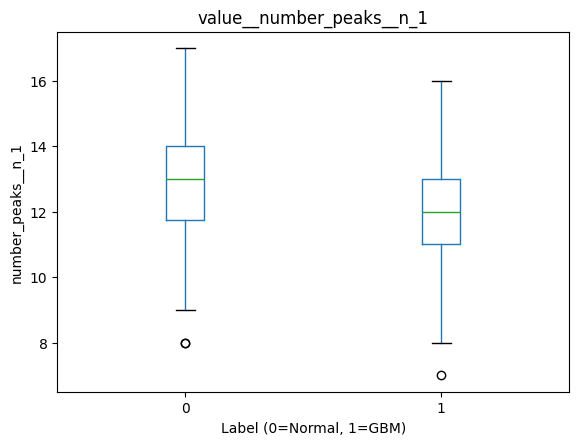

In [33]:
plt.figure(figsize=(6, 4))
Class_features.boxplot(
    column="value__number_peaks__n_1",
    by="label",
    grid=False
)
plt.suptitle("")  # remove default title
plt.xlabel("Label (0=Normal, 1=GBM)")
plt.ylabel("number_peaks__n_1")
plt.show()


In [34]:
Class_features = Class_features.drop(columns=["value__number_peaks__n_1"])

In [35]:
print("Summary statistics for autocorrelation__lag_1:")
print(
    Class_features.groupby("label")["value__autocorrelation__lag_1"].describe()
)

Summary statistics for autocorrelation__lag_1:
       count      mean       std       min       25%       50%       75%  \
label                                                                      
0       60.0  0.443886  0.309808 -0.502099  0.281315  0.463334  0.684084   
1       39.0  0.814424  0.221794  0.017779  0.790024  0.902771  0.926647   

            max  
label            
0      0.936808  
1      0.989659  


<Figure size 600x400 with 0 Axes>

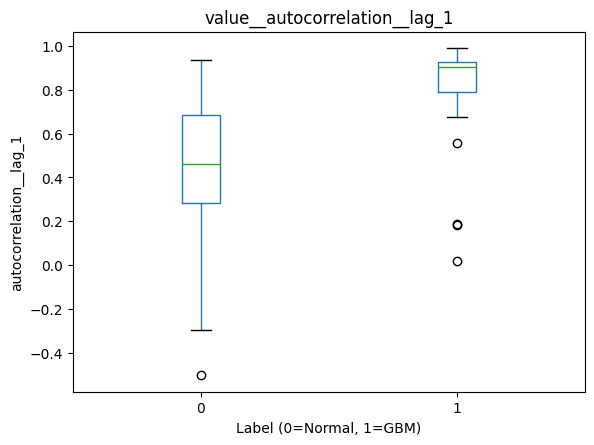

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
Class_features.boxplot(
    column="value__autocorrelation__lag_1",
    by="label",
    grid=False
)
plt.suptitle("") 
plt.xlabel("Label (0=Normal, 1=GBM)")
plt.ylabel("autocorrelation__lag_1")
plt.show()

In [37]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, f1_score, auc, average_precision_score, precision_score, precision_recall_curve

In [38]:
features = Class_features.drop(columns=["id", "label"])
labels   = Class_features["label"]

In [40]:
X = features.values
y = labels.values

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=40, stratify=y)

print("Train shape:", X_train.shape, y_train.shape)
print("Test  shape:", X_test.shape, y_test.shape)

Train shape: (74, 6) (74,)
Test  shape: (25, 6) (25,)


In [42]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

### LOGISTIC REGRESSION

In [44]:
Scaled_LR = LogisticRegression(class_weight="balanced", random_state=40)
Scaled_LR.fit(X_train_scaled, y_train)

y_pred_lr = Scaled_LR.predict(X_test_scaled)
y_proba_lr = Scaled_LR.predict_proba(X_test_scaled)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)

print(f"  Test Accuracy: {acc_lr:.3f}")

  Test Accuracy: 0.960


In [67]:
np.exp(Scaled_LR.coef_)

array([[0.33143594, 5.83517181, 0.31115352, 1.786114  , 0.54458493,
        1.19140456]])

In [46]:
y_train_pred = Scaled_LR.predict(X_train_scaled)
w = accuracy_score(y_train, y_train_pred)
w

0.972972972972973

In [47]:
prec, rec, _ = precision_recall_curve(y_test, y_pred_lr)


pr_auc = auc(rec, prec)
average_precision = average_precision_score(y_test, y_pred_lr)

print(f"PR-AUC Score: {pr_auc:.4f}")

PR-AUC Score: 0.9545


In [48]:
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:")
print(conf_matrix_lr)

Confusion Matrix:
[[14  1]
 [ 0 10]]


In [49]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

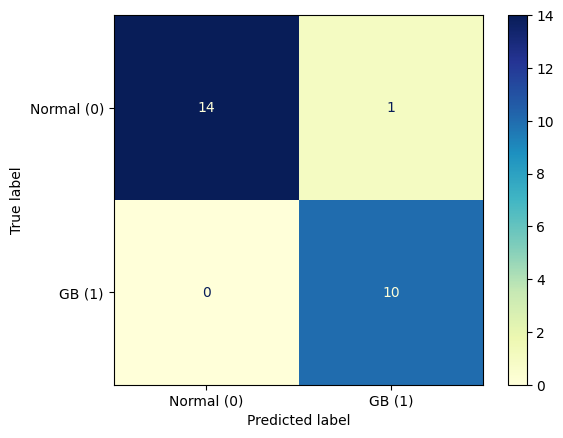

In [69]:
dis = ConfusionMatrixDisplay(conf_matrix_lr, display_labels=["Normal (0)", "GB (1)"])
dis.plot(cmap="YlGnBu", values_format='d')
plt.show()


In [51]:
recall_lr = recall_score(y_test, y_pred_lr)

f1_lr = f1_score(y_test, y_pred_lr)

print(f"Recall: {recall_lr:.3f}")
print(f"F1 Score: {f1_lr:.3f}")

Recall: 1.000
F1 Score: 0.952


### RANDOM FOREST

In [52]:
rf = RandomForestClassifier(class_weight="balanced", random_state=20)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"  Accuracy: {acc_rf:.3f}")

  Accuracy: 0.960


In [53]:
y_train_pred_rf = rf.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred_rf)

print(train_acc)

1.0


In [54]:
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_pred_rf)

pr_auc_rf = auc(rec_rf, prec_rf)

print(f"PR-AUC Score: {pr_auc_rf:.3f}")

PR-AUC Score: 0.970


In [55]:
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
print(conf_matrix_rf)

[[15  0]
 [ 1  9]]


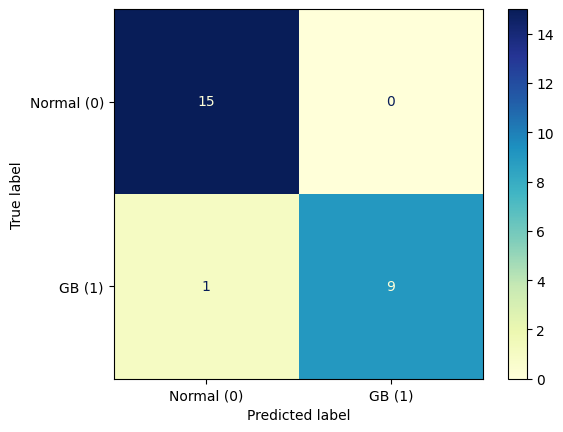

In [56]:
rfC = ConfusionMatrixDisplay(conf_matrix_rf, display_labels=["Normal (0)", "GB (1)"])
rfC.plot(cmap="YlGnBu", values_format='d')
plt.show()

In [57]:
recall_rf = recall_score(y_test, y_pred_rf)

f1_rf = f1_score(y_test, y_pred_rf)

print(f"Recall: {recall_rf:.3f}")
print(f"F1 Score: {f1_rf:.3f}")

Recall: 0.900
F1 Score: 0.947


### SUPPORT VECTOR MACHINES

In [58]:
from sklearn.svm import SVC

svm = SVC(class_weight="balanced", probability=True)

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)
y_proba_svm = svm.predict_proba(X_test_scaled)[:, 1]

acc_svm = accuracy_score(y_test, y_pred_svm)


print(f"  Test accuracy: {acc_svm:.3f}")

  Accuracy: 0.960


In [62]:
train_svm = svm.predict(X_train_scaled)

train_accsvm = accuracy_score(y_train, train_svm)
print(f" Train accuracy: {train_accsvm:.3f}")

 Train accuracy: 0.973


In [63]:
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
print(conf_matrix_svm)

[[15  0]
 [ 1  9]]


In [60]:
recall_svm = recall_score(y_test, y_pred_svm)

f1_svm = f1_score(y_test, y_pred_svm)

print(f"Recall: {recall_svm:.3f}")
print(f"F1 Score: {f1_svm:.3f}")

Recall: 0.900
F1 Score: 0.947


In [61]:
prec_svm, rec_svm, _ = precision_recall_curve(y_test, y_pred_svm)

pr_auc_svm = auc(rec_svm, prec_svm)

print(f"PR-AUC Score: {pr_auc_svm:.3f}")

PR-AUC Score: 0.970


In [432]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=56)

recalls = []

for train_index, test_index in skf.split(X_scaled, y):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y[train_index], y[test_index]

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    recall = recall_score(y_test, y_pred)
    recalls.append(recall)

print("Recall for each fold:", recalls)
print("Average Recall:", np.mean(recalls))

Recall for each fold: [1.0, 1.0, 1.0, 1.0, 0.7142857142857143]
Average Recall: 0.9428571428571428
